<a href="https://colab.research.google.com/github/Huetous/diff-attn-analysis/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import re
import random
import math
import io
import cv2
import os

import torch
import torch.nn.functional as F
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from typing import Callable, List, Optional, Tuple, Union
from tqdm import tqdm

import PIL
import imageio
from IPython.display import Image, display

from collections import Counter, defaultdict

import nltk
from nltk.corpus import stopwords

from datasets import load_dataset
from diffusers.models.attention import Attention

ModuleNotFoundError: No module named 'cv2'

In [2]:
pd.set_option('display.max_colwidth', 150)

In [3]:
!pip install -q datasets==3.6.0
# restart session after this one and run all cells again

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 17.2 MB/s eta 0:00:00


### DrawBench Датасет

**DrawBench Dataset**

Датасет из 200 промптов в 11 категориях (примеры на изображении ниже) <br>
Создан специально для оценки качества text-to-image моделей <br>
Идея в том, чтобы иметь возможность изолированно протестировать различные способности моделей, по типу:
1. генерации объектов определенного цвета
2. генерации определенного количества объектов
3. способности учитывать расположение объектов на изображении и т.д.

В моем случае, это маленький, но достаточно разнообразный датасет. Также, в дальнейшем, разделение на определенные категории может пригодиться

In [5]:
display(Image(filename='assets/drawbench.png'))

In [6]:
dataset = load_dataset("shunk031/DrawBench")["test"]

In [7]:
dataset

Dataset({
    features: ['prompts', 'category'],
    num_rows: 200
})

In [8]:
df = pd.DataFrame(dataset)

200 строк, 2 признака - промпт и его категория

In [9]:
df.shape

(200, 2)

11 уникальных категорий

In [10]:
len(df.category.unique())

11

In [11]:
df.sample(5)

,prompts,category
135,Jentacular.,8
179,A storefront with 'Hello World' written on it.,10
8,A black colored banana.,0
49,Two cats and two dogs sitting on the grass.,2
151,A medieval painting of the wifi not working.,9


Дубликатов нет

In [12]:
df[df.duplicated()]

,prompts,category


Пропусков тоже нет

In [13]:
df.isna().sum()

,0
prompts,0
category,0


Заменим ID категорий на текстовые выражения

In [14]:
df.category.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

In [15]:
categories = [
    "colors", "conflicting", "counting", "DALL-E",
    "description", "Marcus et al.", "misspellings", "positional",
    "rare words", "reddit", "text"
]
categories_map = dict(zip(range(11), categories))
df.category = df.category.map(lambda cat: categories_map[cat])

In [16]:
df.sample(5)

,prompts,category
21,A brown bird and a blue bear.,colors
146,"A fluffy baby sloth with a knitted hat trying to figure out a laptop, close up, highly detailed, studio lighting, screen reflecting in its eyes.",reddit
43,Four dogs on the street.,counting
101,"A donkey and an octopus are playing a game. The donkey is holding a rope on one end, the octopus is holding onto the other. The donkey holds the r...",Marcus et al.
45,One cat and one dog sitting on the grass.,counting


### Анализ содержимого промптов по категориям

Посмотрим на примеры промптов для каждой категории и попытаемся понять их интуитивно

**Colors**

Различные животные, продукты и предметы в конкретных цветах

Эти промпты нужны для проверки способности модели генерировать объекты в конкретном цвете

In [17]:
df[df.category == categories[0]].sample(10)

,prompts,category
22,A black apple and a green backpack.,colors
10,A black colored sandwich.,colors
24,A red book and a yellow vase.,colors
0,A red colored car.,colors
7,A red colored banana.,colors
11,An orange colored sandwich.,colors
17,A green apple and a black backpack.,colors
5,A blue colored dog.,colors
15,A red car and a white sheep.,colors
2,A pink colored car.,colors


**Conflicting**

Противоречивые и неестественные ситуации по типу:
1. Слон под водой
2. Радужный пингвин
3. Акула в пустыне и т.д.

Эти промпты нужны для проверки способности модели генерировать необычные (противоречивые) ситуации, которые скорее всего отсутствовали в обучающей выборке


In [18]:
df[df.category == categories[1]].sample(10)

,prompts,category
29,Hovering cow abducting aliens.,conflicting
27,A bird scaring a scarecrow.,conflicting
30,A panda making latte art.,conflicting
26,A pizza cooking an oven.,conflicting
31,A shark in the desert.,conflicting
34,A fish eating a pelican.,conflicting
25,A horse riding an astronaut.,conflicting
33,Rainbow coloured penguin.,conflicting
32,An elephant under the sea.,conflicting
28,A blue coloured pizza.,conflicting


**Counting**

Проверяем способность модели генерировать определенное количество объектов - не меньше, не больше

In [19]:
df[df.category == categories[2]].sample(10)

,prompts,category
46,One cat and two dogs sitting on the grass.,counting
39,Five cars on the street.,counting
40,One dog on the street.,counting
51,Three cats and one dog sitting on the grass.,counting
41,Two dogs on the street.,counting
50,Two cats and three dogs sitting on the grass.,counting
49,Two cats and two dogs sitting on the grass.,counting
44,Five dogs on the street.,counting
45,One cat and one dog sitting on the grass.,counting
38,Four cars on the street.,counting


**DALL-E**

В описании сказано, что это набор сложных промптов из статьи DALL-E.

Я не заметил какого-то одного паттерна, а несколько групп:
1. Промпты с геометрическими фигурами - куб, треугольник
2. Промпты про расположение предметов относительно друг друга. Как **Positional**, но посложнее
3. Промпты с различными перспективами

In [20]:
df[df.category == categories[3]].sample(10)

,prompts,category
58,A sphere made of kitchen tile. A sphere with the texture of kitchen tile.,DALL-E
66,"A stack of 3 plates. A blue plate is on the top, sitting on a blue plate. The blue plate is in the middle, sitting on a green plate. The green pla...",DALL-E
67,"A stack of 3 cubes. A red cube is on the top, sitting on a red cube. The red cube is in the middle, sitting on a green cube. The green cube is on ...",DALL-E
65,A small blue book sitting on a large red book.,DALL-E
59,A cube made of brick. A cube with the texture of brick.,DALL-E
57,A cube made of denim. A cube with the texture of denim.,DALL-E
69,"An emoji of a baby panda wearing a red hat, green gloves, red shirt, and green pants.",DALL-E
55,A triangular orange picture frame. An orange picture frame in the shape of a triangle.,DALL-E
63,An illustration of a large red elephant sitting on a small blue mouse.,DALL-E
62,A couple of glasses are sitting on a table.,DALL-E


**Description**

В этих промптах не используется название объекта, а только его описание.
Тем самым можно проверить существует ли семантическая связь объект-описание внутри модели

In [21]:
df[df.category == categories[4]].sample(10)

,prompts,category
77,A connection point by which firefighters can tap into a water supply.,description
74,"A vehicle composed of two wheels held in a frame one behind the other, propelled by pedals and steered with handlebars attached to the front wheel.",description
85,A long curved fruit which grows in clusters and has soft pulpy flesh and yellow skin when ripe.,description
78,"A machine next to a parking space in a street, into which the driver puts money so as to be authorized to park the vehicle for a particular length...",description
84,"A large plant-eating domesticated mammal with solid hoofs and a flowing mane and tail, used for riding, racing, and to carry and pull loads.",description
87,"A domesticated carnivorous mammal that typically has a long snout, an acute sense of smell, nonretractable claws, and a barking, howling, or whini...",description
83,"An instrument used for cutting cloth, paper, and other thin material, consisting of two blades laid one on top of the other and fastened in the mi...",description
80,"A separate seat for one person, typically with a back and four legs.",description
79,"A device consisting of a circular canopy of cloth on a folding metal frame supported by a central rod, used as protection against rain or sometime...",description
88,"An organ of soft nervous tissue contained in the skull of vertebrates, functioning as the coordinating center of sensation and intellectual and ne...",description


**Marcus et al.**

Я заметил следующие паттерны:
1. Промпты с детально описанной сценой - конкретное расположение и участники, присутствие конкретных объектов в конкретном месте
2. Есть один промпт с игрой слов:
    "Paying for a quarter-sized pizza with a pizza-sized quarter." <br>


Но большинство промптов - просто детальные описания конкретных сцен

In [22]:
df[df.category == categories[5]].sample(10)

,prompts,category
94,Paying for a quarter-sized pizza with a pizza-sized quarter.,Marcus et al.
95,An oil painting of a couple in formal evening wear going home get caught in a heavy downpour with no umbrellas.,Marcus et al.
98,An elephant is behind a tree. You can see the trunk on one side and the back legs on the other.,Marcus et al.
103,Abraham Lincoln touches his toes while George Washington does chin-ups. Lincoln is barefoot. Washington is wearing boots.,Marcus et al.
99,A tomato has been put on top of a pumpkin on a kitchen stool. There is a fork sticking into the pumpkin. The scene is viewed from above.,Marcus et al.
97,"In late afternoon in January in New England, a man stands in the shadow of a maple tree.",Marcus et al.
101,"A donkey and an octopus are playing a game. The donkey is holding a rope on one end, the octopus is holding onto the other. The donkey holds the r...",Marcus et al.
100,A pear cut into seven pieces arranged in a ring.,Marcus et al.
102,"Supreme Court Justices play a baseball game with the FBI. The FBI is at bat, the justices are on the field.",Marcus et al.
96,"A grocery store refrigerator has pint cartons of milk on the top shelf, quart cartons on the middle shelf, and gallon plastic jugs on the bottom s...",Marcus et al.


**Missspellings**

Промпты с орфографическими ошибками.

По сути - промпты с некоторым шумом. Можно проверить чуствительность модели к такому шуму. В идеале, промпты с шумом и их эталоны должны быть достаточно близко во внутреннем пространстве модели, для того, чтобы сгенерировалось адекватное изображение

In [23]:
df[df.category == categories[6]].sample(10)

,prompts,category
108,Pafrking metr.,misspellings
112,"A domesticated carnivvorous mzammal that typicbally hfaas a lons sfnout, an acxujte sense off osmell, noneetractaaln crlaws, anid xbarkring,y howl...",misspellings
106,Rbefraigerator.,misspellings
113,"A ldarge keybord msical instroument lwith a woden case enmclosig a qsouvnkboajrd and mfgtal strivgf, which are strucrk b hammrs when the nels are ...",misspellings
104,Tcennis rpacket.,misspellings
105,Bzaseball galove.,misspellings
110,"A sjmall domesticated carnivorious mammnal with sof fuh,y a sthort sout, and retracwtablbe flaws. It iw widexly kept as a pet or for catchitng mic...",misspellings
109,"A smafml vessef epropoeilled on watvewr by ors, sauls, or han engie.",misspellings
111,"An instqrumemnt used for cutting cloth, paper, axdz othr thdin mteroial, consamistng of two blades lad one on tvopb of the other and fhastned in t...",misspellings
107,Dininrg tablez.,misspellings


**Positional**

В этих промптах есть два объекта и они как-то расположены относительно друг друга. Можно проверить понимание модели расположения объектов в пространстве

In [24]:
df[df.category == categories[7]].sample(10)

,prompts,category
120,A donut underneath a toilet.,positional
126,A car on the left of a bus.,positional
125,A couch on the left of a chair.,positional
117,An umbrella on top of a spoon.,positional
119,A giraffe underneath a microwave.,positional
131,A stop sign on the right of a refrigerator.,positional
124,A banana on the left of an apple.,positional
127,A cat on the left of a dog.,positional
129,A pizza on the right of a suitcase.,positional
132,A sheep to the right of a wine glass.,positional


**Rare words**

Я бы сказал очень редкие - первый раз такие вижу

In [25]:
df[df.category == categories[8]]

,prompts,category
134,Acersecomicke.,rare words
135,Jentacular.,rare words
136,Matutinal.,rare words
137,Peristeronic.,rare words
138,Artophagous.,rare words
139,Backlotter.,rare words
140,Octothorpe.,rare words


**Reddit**

Необычные сюжеты с совмещением объектов и ситуаций, которые в реальном мире не встречаются вместе:
1. Египет и вынос мусора
2. Марио и фото в реальной жизни
3. Мышь и зонтик и т.д.


In [26]:
df[df.category == categories[9]].sample(10)

,prompts,category
174,Darth Vader playing with raccoon in Mars during sunset.,reddit
176,Illustration of a mouse using a mushroom as an umbrella.,reddit
177,A realistic photo of a Pomeranian dressed up like a 1980s professional wrestler with neon green and neon orange face paint and bright green wrestl...,reddit
152,"An IT-guy trying to fix hardware of a PC tower is being tangled by the PC cables like Laokoon. Marble, copy after Hellenistic original from ca. 20...",reddit
165,"A real life photography of super mario, 8k Ultra HD.",reddit
150,A yellow and black bus cruising through the rainforest.,reddit
169,A photocopy of a photograph of a painting of a sculpture of a giraffe.,reddit
156,Greek statue of a man tripping over a cat.,reddit
144,A photo of a confused grizzly bear in calculus class.,reddit
151,A medieval painting of the wifi not working.,reddit


**Text**

Проверка способности модели генерировать изображения с конкретным текстом-фразой

In [27]:
df[df.category == categories[10]].sample(10)

,prompts,category
189,A sign that says 'NeurIPS'.,text
191,A sign that says 'Google Brain Toronto'.,text
196,New York Skyline with 'NeurIPS' written with fireworks on the sky.,text
188,A sign that says 'Text to Image'.,text
183,A storefront with 'Deep Learning' written on it.,text
194,New York Skyline with 'Diffusion' written with fireworks on the sky.,text
179,A storefront with 'Hello World' written on it.,text
190,A sign that says 'Deep Learning'.,text
187,A sign that says 'Diffusion'.,text
181,A storefront with 'Text to Image' written on it.,text


### Анализ статистик промптов

#### Частоты категорий промптов

In [28]:
df.category.value_counts()

,count
category,
reddit,38
colors,25
text,21
positional,20
description,20
DALL-E,20
counting,19
conflicting,10
Marcus et al.,10


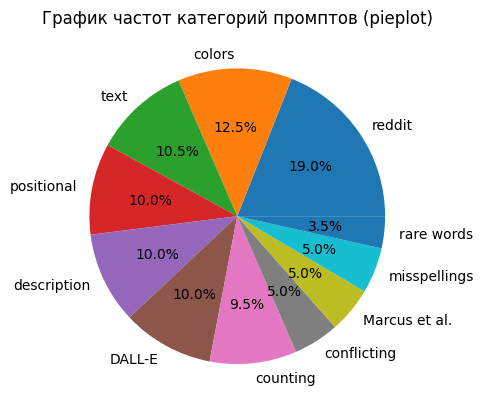

In [29]:
data = df.category.value_counts().values
labels = df.category.value_counts().index
plt.pie(data, labels=labels, autopct='%.1f%%')
plt.title('График частот категорий промптов (pieplot)')
plt.show()

Видно, что категории распределены неравномерно

Топ-3 категорий:
1. Reddit - необычные (вымышленные) ситуации
2. Colors - генерация объектов определенного цвета
3. Text - генерация конкретного текста

#### Длина промпта

In [30]:
df["char_count"] = df.prompts.map(lambda x: len(x))

Статистики длины промпта:
* Минимальная длина - 10 символов
* Максимальная длина - 303 символов
* Средняя длина - 64.16 символов
* Медианная длина - 44 символа

In [31]:
df["char_count"].agg(["min", "mean", "median", "max"])

,char_count
min,10.00
mean,64.16
median,44.00
max,303.00


Промпт с минимальной длиной

In [32]:
df[df.char_count == df.char_count.min()]

,prompts,category,char_count
136,Matutinal.,rare words,10


Промпт с максимальной длиной

Категория - description - описание объектов

В данном случае - пианино

In [33]:
str(df[df.char_count == df.char_count.max()].prompts.values[0])

"A ldarge keybord msical instroument lwith a woden case enmclosig a qsouvnkboajrd and mfgtal strivgf, which are strucrk b hammrs when the nels are depresdsmed.f lhe strsingsj' vibration ie stopped by damperds when the keys re released and can bce regulavewdd for lengh and vnolume y two or three pedalvs."

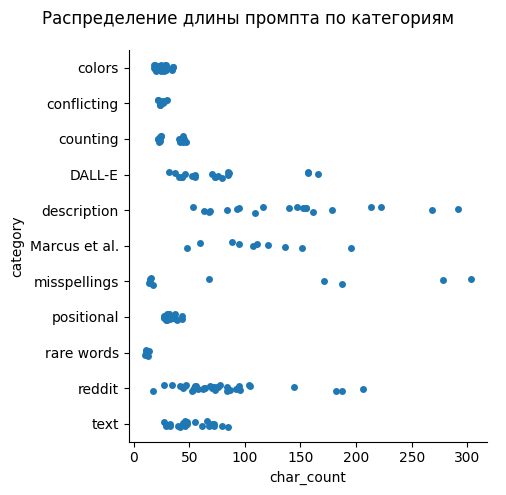

In [34]:
ax = sns.catplot(data=df, x="char_count", y="category")
ax.fig.subplots_adjust(top=0.9)
ax = ax.fig.suptitle("Распределение длины промпта по категориям")

Можно выделить несколько групп промптов:
* Короткие (до 50 символов) - colors, counting, conflicting, positional, rare words
* Средние (до 200 символов) - reddit, DALL-E, text, Marcus et al.
* Длинные (до 300 символов) - mispellings, description

In [35]:
df.groupby("category").char_count.agg(["min", "mean", "median", "max"]).sort_values(by="max", ascending=False)

,min,mean,median,max
category,,,,
misspellings,14,108.400000,42.5,303
description,53,141.650000,143.5,292
reddit,17,77.210526,69.5,206
Marcus et al.,48,111.200000,109.0,195
DALL-E,32,75.550000,71.5,166
text,27,52.142857,48.0,85
counting,22,33.105263,25.0,47
positional,27,32.950000,32.0,43
colors,18,25.600000,25.0,35


#### Кол-во слов в промпте

Разобъем промпты по пробелу и посчитаем кол-во слов в каждом промпте

In [36]:
df["word_count"] = df.prompts.map(lambda x: len(x.split()))

Примеры промптов длиной меньше 10 слов

In [37]:
df[df.word_count < 10].sample(5)

,prompts,category,char_count,word_count
47,One cat and three dogs sitting on the grass.,counting,44,9
187,A sign that says 'Diffusion'.,text,29,5
11,An orange colored sandwich.,colors,27,4
35,One car on the street.,counting,22,5
82,A mechanical or electrical device for measuring time.,description,53,8


Статистики кол-ва слов в промпте по всем категориям:
* Средняя длина промпта: 11.685 слов
* Медианная длина промпта: 9 слов

In [38]:
df["word_count"].agg(["min", "mean", "median", "max"])

,word_count
min,1.000
mean,11.685
median,9.000
max,51.000


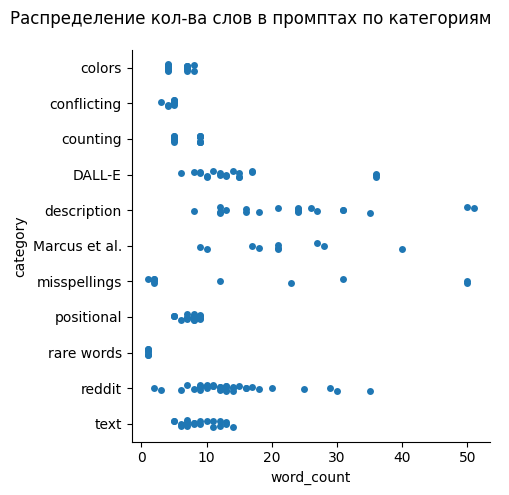

In [39]:
ax = sns.catplot(data=df, x="word_count", y="category")
ax.fig.subplots_adjust(top=0.9)
ax = ax.fig.suptitle("Распределение кол-ва слов в промптах по категориям")

Можно выделить несколько групп промптов:
1. Короткие (до 10 слов) - colors, counting, conflicting, positional, rare words
2. Средние (до 40 слов) - reddit, DALL-E, text, Marcus et al.
3. Длинные (до 50 слов) - mispellings, description

In [40]:
df.groupby("category").word_count.agg(["min", "mean", "median", "max"]).sort_values(by="max", ascending=False)

,min,mean,median,max
category,,,,
description,8,23.750000,24.0,51
misspellings,1,17.500000,7.0,50
Marcus et al.,9,21.200000,21.0,40
DALL-E,6,15.700000,13.0,36
reddit,2,13.368421,12.0,35
text,5,8.952381,8.0,14
positional,5,7.450000,8.0,9
counting,5,6.894737,5.0,9
colors,4,5.280000,4.0,8


Самый короткий промпт - 1 слово

In [41]:
df[df.word_count == df.word_count.min()]

,prompts,category,char_count,word_count
106,Rbefraigerator.,misspellings,15,1
134,Acersecomicke.,rare words,14,1
135,Jentacular.,rare words,11,1
136,Matutinal.,rare words,10,1
137,Peristeronic.,rare words,13,1
138,Artophagous.,rare words,12,1
139,Backlotter.,rare words,11,1
140,Octothorpe.,rare words,11,1


Самый длинный промпт - 51 слово

In [42]:
df[df.word_count == df.word_count.max()]

,prompts,category,char_count,word_count
83,"An instrument used for cutting cloth, paper, and other thin material, consisting of two blades laid one on top of the other and fastened in the mi...",description,268,51


Этот промпт описывает ножницы

In [43]:
str(df[df.word_count == df.word_count.max()].prompts.values[0])

'An instrument used for cutting cloth, paper, and other thin material, consisting of two blades laid one on top of the other and fastened in the middle so as to allow them to be opened and closed by a thumb and finger inserted through rings on the end of their handles.'

#### Связь длины промпта и кол-ва слов в нем

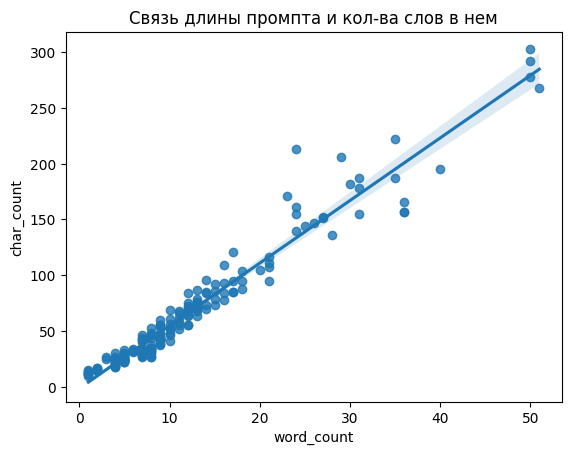

In [44]:
ax = sns.regplot(x=df.word_count, y=df.char_count)
ax = ax.set_title("Связь длины промпта и кол-ва слов в нем")

Видно, что в общем связь линейная - чем больше слов в промпте, тем длиньше промпт

Также, заметим, что:
* если точка ВЫШЕ прямой - значит в ней используются более длинные слова
* если точка НИЖЕ прямой - значит в ней используются более короткие слова

#### Анализ частот уникальных слов

In [45]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Примеры стоп-слов в Английском языке

In [46]:
random.choices(stopwords.words('english'), k=15)

['we',
 'm',
 "they'll",
 'this',
 'just',
 'from',
 "won't",
 'd',
 "you'd",
 'then',
 'd',
 'do',
 'than',
 "haven't",
 'doesn']

Для каждого промпта выполним следующее:
1. Приведем к нижнему регистру
2. Удалим все символы, кроме букв Английского алфавита, цифр и дефиса
3. Удалим все стоп-слова

In [47]:
def preprocess(prompt):
    prompt = prompt.lower()
    prompt = re.sub('[^a-z A-Z 0-9-]+', '', prompt)
    prompt = " ".join([word for word in prompt.split() if word not in stopwords.words('english')])
    return prompt

In [48]:
df["raw_prompts"] = df.prompts.apply(preprocess)

Сравним результат до и после

In [49]:
df["prompts"].tail(3)

,prompts
197,New York Skyline with 'Deep Learning' written with fireworks on the sky.
198,New York Skyline with 'Google Brain Toronto' written with fireworks on the sky.
199,New York Skyline with 'Google Research Pizza Cafe' written with fireworks on the sky.


In [50]:
df["raw_prompts"].tail(3)

,raw_prompts
197,new york skyline deep learning written fireworks sky
198,new york skyline google brain toronto written fireworks sky
199,new york skyline google research pizza cafe written fireworks sky


Создадим счетчик слов для каждого промпта

In [51]:
df["raw_prompt_wc"] = df.raw_prompts.apply(lambda p: Counter(p.split()))

Функция ниже делает следующее:
1. Идет по всем промптам конкреткой категории
2. Берет счетчик слов каждого промпта и объединяет в один большой счетчик.
3. Возвращает топ-5 часто встречающихся слов для всей категории


In [52]:
def most_common_words(df, category):
    total = {}
    data = df[df.category == category].raw_prompt_wc
    for i in range(len(data)):
        total.update(data.iloc[i])
    return Counter(total).most_common(5)

Выведем категории, в которых есть слова, встречающиеся больше одного раза

Если какой-то категории нет - значит все слова, соответсвующие ей, встречаются только один раз

In [53]:
for cat in categories:
    wcs = most_common_words(df, cat)
    if any([c > 1 for w, c in wcs]):
        print(cat.upper())
        for w, c in wcs:
            if c > 1:
                print(f"{w}: {c}")
        print()

COUNTING
three: 2

DALL-E
cube: 5
book: 5
plate: 5
purple: 2
flower: 2

DESCRIPTION
large: 2
nervous: 2
computing: 2
strings: 2
keys: 2

MARCUS ET AL.
shelf: 3
donkey: 3
rope: 3
cartons: 2
pumpkin: 2

REDDIT
orange: 2
light: 2
pc: 2
water: 2
mona: 2



Видно, что в целом в каждой категории слова различны

В категории DALL-E, слова куб, книга и тарелка встречаются по 5 раз каждое.

При этом всего промптов данной категории - 20. Довольно часто

In [54]:
df[df.category == "DALL-E"].shape

(20, 6)

Составим глобальный счетчик слов для всего датасета

In [55]:
df_wc = {}
for cat in categories:
    df_wc.update(most_common_words(df, cat))
Counter(df_wc).most_common(10)

[('cube', 5),
 ('book', 5),
 ('plate', 5),
 ('shelf', 3),
 ('donkey', 3),
 ('rope', 3),
 ('three', 2),
 ('purple', 2),
 ('flower', 2),
 ('large', 2)]

Счетчики слов не поменялись - значит категории не пересекаются

### Аугментации

Для моей задачи это не актуально, т.к. я не буду обучать модель, а только визуализировать внутреннее устройство

Но чисто теоретически, для текста существуют следующие простые виды аугментаций:

**Замена сущностей** <br>
1. Создать списки категорий объектов по типу
```
    animals = ["cat", "dog", ...]
    colors = ["red", "blue", ...]
    ...
```
2. Для каждого промпта, к примеру, найти цвет ("red") и заменить на рандомный из соответсвующего сета ("blue").
3. Тем самым, структура останется такой же, но зато появится вариативность в конкретных сущностях

**Замена на синонимы** <br>
Находить в тексте слова по типу "large" и заменять на "huge", "big", и т.д.

**Удаление слов** <br>
Удалять слова с небольшой вероятностью

In [56]:
# Подумать про аугментацию данных и проверить различные способы аугментации - описать их и сказать, подходят ли для выбранной задачи.

### Общие выводы

Из анализа выше, можно сделать следующие выводы

* Категории распределены не равномерно

* В среднем, большинство промптов достаточно короткие

* Промпты достаточно уникальны и не повторяются между собой, и между категориями

* Также, можно выделить следующие группы промптов. Я их отсортировал от простого к сложному (примерно).
    1. Четкое условие (меньше возможных вариантов)
    * Определенное количество объектов
    * Определенный цвет объектов
    * Генерация текста
    2. Простое и сложное расположение объектов
    3. Недостаток, избыток или искажение информации:
    * Описание объекта вместо названия объекта
    * Очень детальные описания сцен
    * Орфографические ошибки
    4. Что-то необычное или редкое:
    * Нереалестичные объекты и ситуации
    * Противоречивые ситуации
    * Редкие слова

Как это пригодится для моей задачи:
1. Датасет можно разбить на категории (задачи), а сами категории отсортировать по сложности. Тем самым, я смогу побирать промпты под конкретную ситуацию или эксперимент. В зависимости от того, что я захочу протестировать или показать.
2. Датасет небольшой, результаты модели можно будет визуально просмотреть и проанализировать
3. Благодаря тому, что промпты короткие, размер attention maps будет небольшим. Насколько я знаю, зависимость квадратичная для стандартных имплементаций

В общем, датасет достаточно разнообразный, при этом не очень большой. Кажется, хороший вариант

### Baseline

#### Подготовка

In [3]:
def make_image_grid(images, inches=2, nrows=None, title="", subtitle="", top=0.8,
                    tight=False, overlap_with=None, return_buffer=False):
    N = len(images)
    if nrows is None:
        nrows = min(int(math.sqrt(N)), 8)
    ncols = math.ceil(N / nrows)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(ncols * inches, nrows * inches)
    )
    axes = np.array(axes).flatten()

    for i in range(len(axes)):
        if i < N:
            axes[i].imshow(images[i], cmap=None)
            if overlap_with is not None:
                axes[i].imshow(overlap_with, alpha=0.2)
        axes[i].axis('off')
        if subtitle:
            axes[i].set_title(subtitle.format(i))

    if title:
        plt.suptitle(title)

    if tight:
        fig.subplots_adjust(left=0.0, right=1.0, top=1.0, bottom=0.0,
                            wspace=0.0, hspace=0.0)
    else:
        plt.tight_layout() # auto overlap prevention
        plt.subplots_adjust(top=top)

    if return_buffer:
        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        plt.close()
        buf.seek(0)
        return buf
    else:
        plt.show()

In [4]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "sd-legacy/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)
pipe.safety_checker = None
pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [5]:
prompt = "A cat"
images = pipe(prompt=[prompt] * 7, num_inference_steps=5).images

  0%|          | 0/5 [00:00<?, ?it/s]

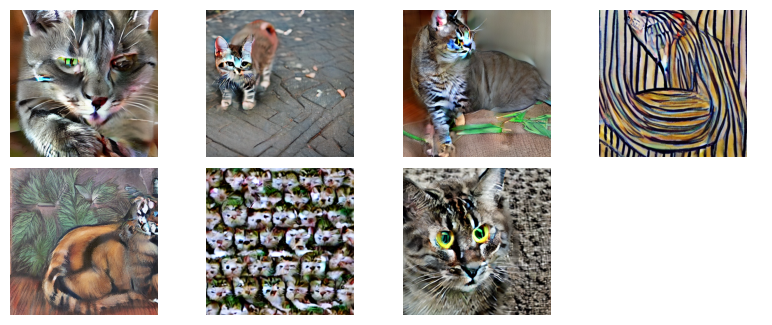

In [10]:
make_image_grid(images)

#### Визуализация карт внимания

In [5]:
# Скопировал из diffusers, добавил только логирование
class AttnProcessor2_0WithLogging:
    r"""
    Processor for implementing scaled dot-product attention (enabled by default if you're using PyTorch 2.0).
    """

    def __init__(self):
        self.layer_name = None
        if not hasattr(F, "scaled_dot_product_attention"):
            raise ImportError("AttnProcessor2_0 requires PyTorch 2.0, to use it, please upgrade PyTorch to 2.0.")

    def __call__(
        self,
        attn,
        hidden_states: torch.Tensor,
        encoder_hidden_states: Optional[torch.Tensor] = None,
        attention_mask: Optional[torch.Tensor] = None,
        temb: Optional[torch.Tensor] = None,
        *args,
        **kwargs,
    ) -> torch.Tensor:
        # if len(args) > 0 or kwargs.get("scale", None) is not None:
        #     deprecation_message = "The `scale` argument is deprecated and will be ignored. Please remove it, as passing it will raise an error in the future. `scale` should directly be passed while calling the underlying pipeline component i.e., via `cross_attention_kwargs`."
        #     deprecate("scale", "1.0.0", deprecation_message)

        residual = hidden_states
        if attn.spatial_norm is not None:
            hidden_states = attn.spatial_norm(hidden_states, temb)

        input_ndim = hidden_states.ndim

        if input_ndim == 4:
            batch_size, channel, height, width = hidden_states.shape
            hidden_states = hidden_states.view(batch_size, channel, height * width).transpose(1, 2)

        batch_size, sequence_length, _ = (
            hidden_states.shape if encoder_hidden_states is None else encoder_hidden_states.shape
        )

        if attention_mask is not None:
            attention_mask = attn.prepare_attention_mask(attention_mask, sequence_length, batch_size)
            # scaled_dot_product_attention expects attention_mask shape to be
            # (batch, heads, source_length, target_length)
            attention_mask = attention_mask.view(batch_size, attn.heads, -1, attention_mask.shape[-1])

        if attn.group_norm is not None:
            hidden_states = attn.group_norm(hidden_states.transpose(1, 2)).transpose(1, 2)

        query = attn.to_q(hidden_states)

        is_cross = True
        if encoder_hidden_states is None:
            encoder_hidden_states = hidden_states
            is_cross = False
        elif attn.norm_cross:
            encoder_hidden_states = attn.norm_encoder_hidden_states(encoder_hidden_states)

        key = attn.to_k(encoder_hidden_states)
        value = attn.to_v(encoder_hidden_states)

        inner_dim = key.shape[-1]
        head_dim = inner_dim // attn.heads

        query = query.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        key = key.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)
        value = value.view(batch_size, -1, attn.heads, head_dim).transpose(1, 2)

        if attn.norm_q is not None:
            query = attn.norm_q(query)
        if attn.norm_k is not None:
            key = attn.norm_k(key)

        # =======Logging========
        attention_map = compute_attention_map(
            query, key, attn_mask=attention_mask
        )
        save_attention_map(attention_map, self.layer_name, is_cross)
        # ======================

        # the output of sdp = (batch, num_heads, seq_len, head_dim)
        # TODO: add support for attn.scale when we move to Torch 2.1
        hidden_states = F.scaled_dot_product_attention(
            query, key, value, attn_mask=attention_mask, dropout_p=0.0, is_causal=False
        )

        hidden_states = hidden_states.transpose(1, 2).reshape(batch_size, -1, attn.heads * head_dim)
        hidden_states = hidden_states.to(query.dtype)

        # linear proj
        hidden_states = attn.to_out[0](hidden_states)
        # dropout
        hidden_states = attn.to_out[1](hidden_states)

        if input_ndim == 4:
            hidden_states = hidden_states.transpose(-1, -2).reshape(batch_size, channel, height, width)

        if attn.residual_connection:
            hidden_states = hidden_states + residual

        hidden_states = hidden_states / attn.rescale_output_factor

        return hidden_states

In [6]:
def compute_attention_map(query, key, attn_mask=None, scale=None):
    L, S = query.size(-2), key.size(-2)
    scale_factor = 1 / math.sqrt(query.size(-1)) if scale is None else scale
    attn_bias = torch.zeros(L, S, dtype=query.dtype, device=query.device)

    if attn_mask is not None:
        if attn_mask.dtype == torch.bool:
            attn_bias.masked_fill_(attn_mask.logical_not(), float("-inf"))
        else:
            attn_bias = attn_mask + attn_bias

    attn_weight = query @ key.transpose(-2, -1) * scale_factor
    attn_weight += attn_bias
    attn_weight = torch.softmax(attn_weight, dim=-1)
    return attn_weight

def save_attention_map(attention_map, layer_name, is_cross):
    attention_map = attention_map.detach().cpu().to(torch.float16)
    if is_cross:
        cross_attention_maps[layer_name].append(attention_map)
    # else:
        # self_attention_maps[layer_name].append(attention_map)

def process_attn_maps(inp_maps, token_indices):
    conditional_part = 1
    inp_maps = torch.stack(inp_maps, dim=0)
    inp_maps = inp_maps[:, conditional_part, ...]
    inp_maps = inp_maps[..., token_indices]
    inp_maps = inp_maps.sum(-1)
    # shape: [timestamps, heads, width * width]

    w = int(inp_maps.shape[2] ** 0.5)
    out_maps = inp_maps.reshape(
        *inp_maps.shape[:2],
        w,
        w,
    )
    # shape: [timestamps, heads, width, width]

    return out_maps

def pt_to_img_list(pt):
    if len(pt.shape) == 3:
        pt_list = torch.split(pt, 1, 0)
        return [item.squeeze().numpy() for item in pt_list]
    elif len(pt.shape) == 2:
        return [pt.numpy()]
    else:
        raise ValueError(f"Invalid input shape: {pt.shape}")

In [7]:
def aggregated_viz(maps_dict, token_indices, agg=None, agg_dims=0,
                   title="", subtitle="", top=0.8):
    attn_maps = process_attn_maps(
        maps_dict,
        token_indices
    )

    if agg in ["mean", "max"]:
        if agg == "mean":
            attn_maps = attn_maps.mean(agg_dims, keepdim=True)
        elif agg == "max":
            attn_maps = attn_maps.amax(dim=agg_dims, keepdim=True)

    for i in range(len(attn_maps)):
        make_image_grid(
            pt_to_img_list(attn_maps[i]),
            title=title.format(i),
            subtitle=subtitle,
            top=top
        )

Заменяем attention на кастомный с логированием

In [8]:
attn_processors = {}

for name, module in pipe.unet.named_modules():
    if isinstance(module, Attention):
        processor = AttnProcessor2_0WithLogging()
        processor.layer_name = name
        attn_processors[f"{name}.processor"] = processor

pipe.unet.set_attn_processor(attn_processors)

Создаем dict для сохранения карт

In [9]:
cross_attention_maps = defaultdict(list)

prompt = "A cat on a beach"
image = pipe(
    prompt=prompt,
    num_inference_steps=30
).images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

Находим нужный токен

In [10]:
token = "cat"
input_ids =  pipe.tokenizer(prompt)["input_ids"]
token_strings = pipe.tokenizer.convert_ids_to_tokens(input_ids)
print(token_strings)

['<|startoftext|>', 'a</w>', 'cat</w>', 'on</w>', 'a</w>', 'beach</w>', '<|endoftext|>']


Добавляем в subwords и находим все индексы

Слово может разбиться на несколько токенов

In [11]:
subwords = ['cat</w>']
token_indices = [i for i, t in enumerate(token_strings) if t in subwords ]
token_indices

[2]

Generated image

Смотрим, что сгенерировалось

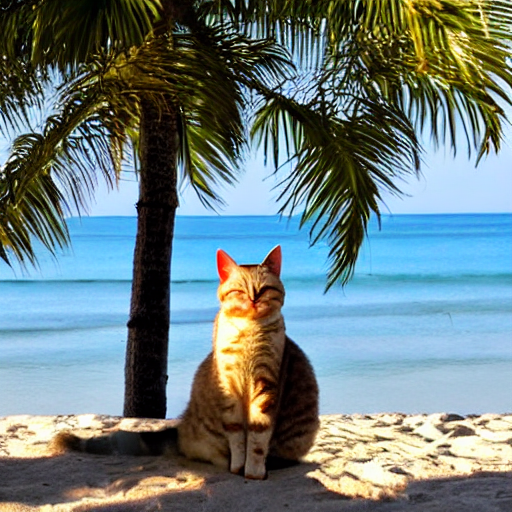

In [12]:
image

Все доступные слои для визуализации

In [201]:
layer_names = list(cross_attention_maps.keys())
layer_names

['down_blocks.0.attentions.0.transformer_blocks.0.attn2',
 'down_blocks.0.attentions.1.transformer_blocks.0.attn2',
 'down_blocks.1.attentions.0.transformer_blocks.0.attn2',
 'down_blocks.1.attentions.1.transformer_blocks.0.attn2',
 'down_blocks.2.attentions.0.transformer_blocks.0.attn2',
 'down_blocks.2.attentions.1.transformer_blocks.0.attn2',
 'mid_block.attentions.0.transformer_blocks.0.attn2',
 'up_blocks.1.attentions.0.transformer_blocks.0.attn2',
 'up_blocks.1.attentions.1.transformer_blocks.0.attn2',
 'up_blocks.1.attentions.2.transformer_blocks.0.attn2',
 'up_blocks.2.attentions.0.transformer_blocks.0.attn2',
 'up_blocks.2.attentions.1.transformer_blocks.0.attn2',
 'up_blocks.2.attentions.2.transformer_blocks.0.attn2',
 'up_blocks.3.attentions.0.transformer_blocks.0.attn2',
 'up_blocks.3.attentions.1.transformer_blocks.0.attn2',
 'up_blocks.3.attentions.2.transformer_blocks.0.attn2']

Опции аггреагиции:
1. Tokens - интересующий токен задается выше
2. Слои (down, middle, up) - в каждом по несколько attention layers
3. Timestamps - шаги генерации
4. Heads - у каждого attention layers по 8 голов

In [20]:
# задаем нужный индекс токена
# Если их несколько, то просуммируем по всем
token_indices = [2]

# задаем нужный слой
layer_id = 0
layer_name = layer_names[layer_id]
print(layer_name)

down_blocks.0.attentions.0.transformer_blocks.0.attn2


In [28]:
cross_attention_maps[layer_name][0][1].reshape(8, 64, 64, 77).shape

torch.Size([8, 64, 64, 77])

##### No aggregation

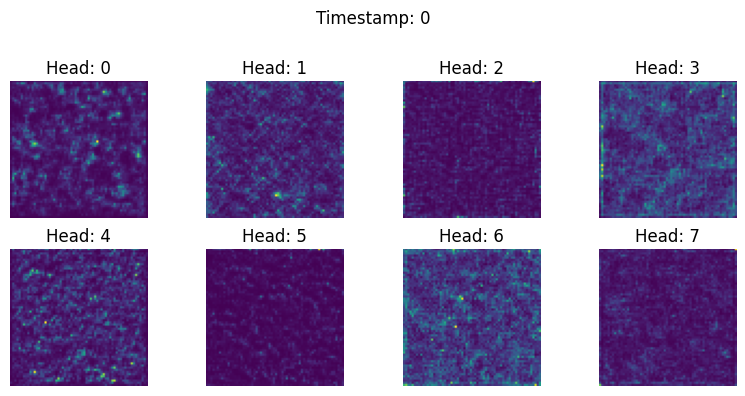

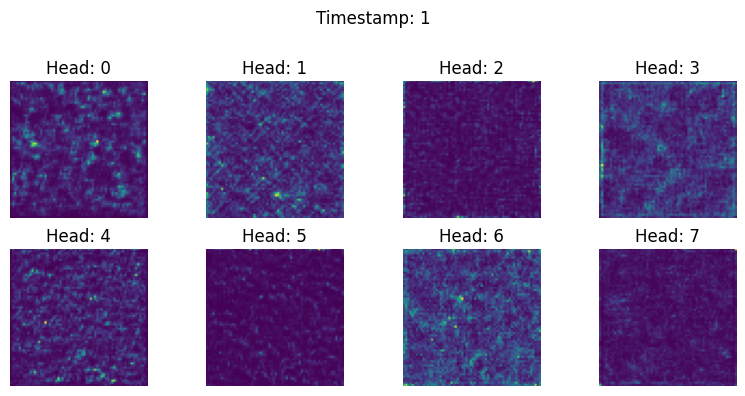

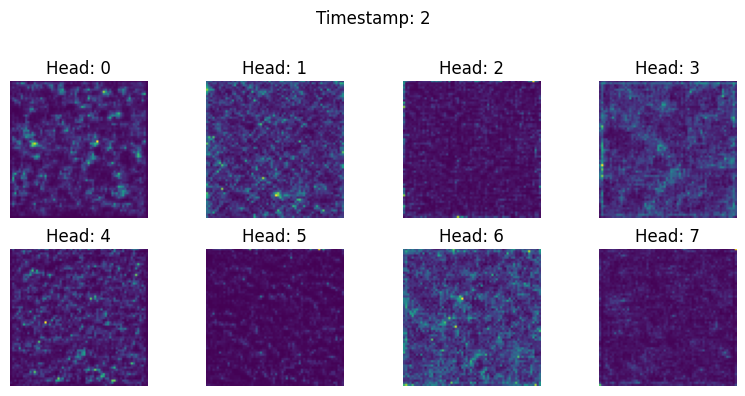

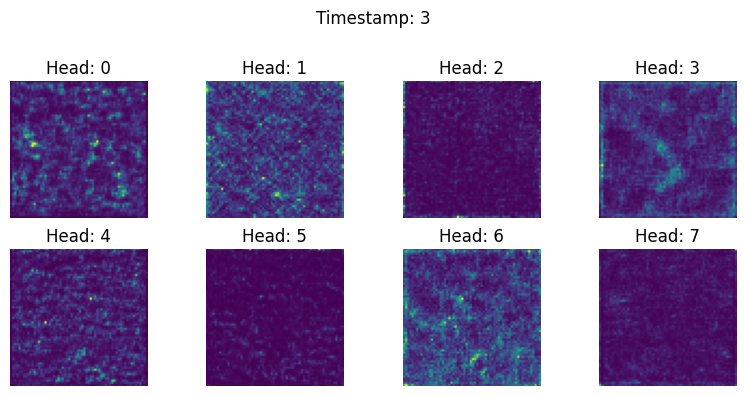

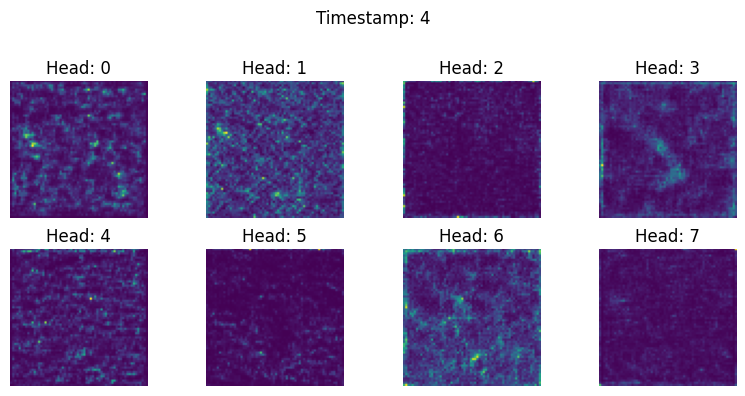

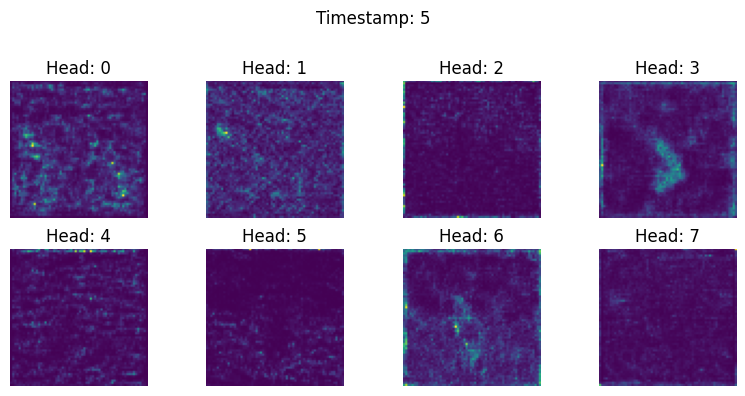

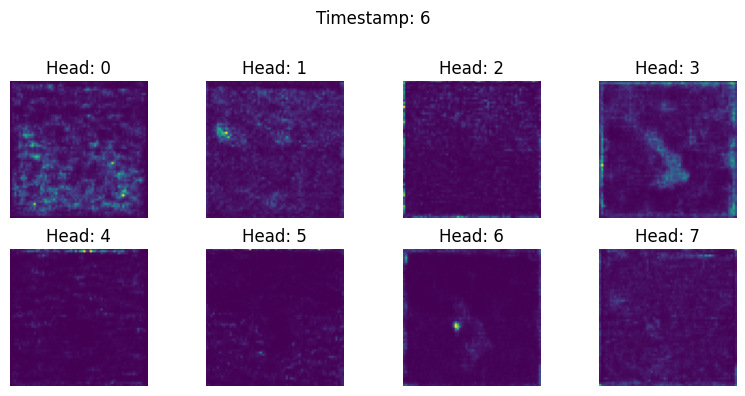

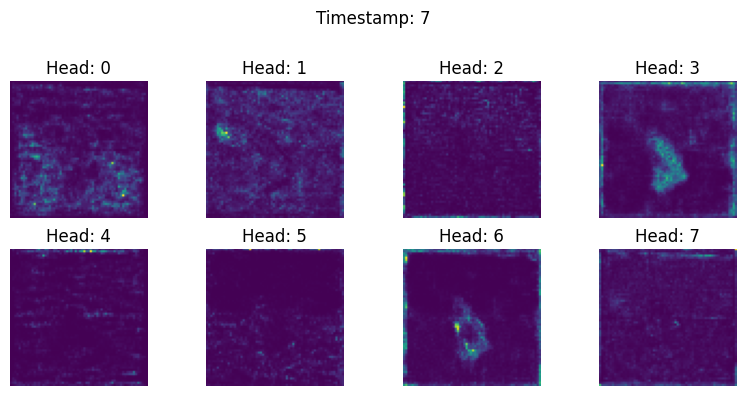

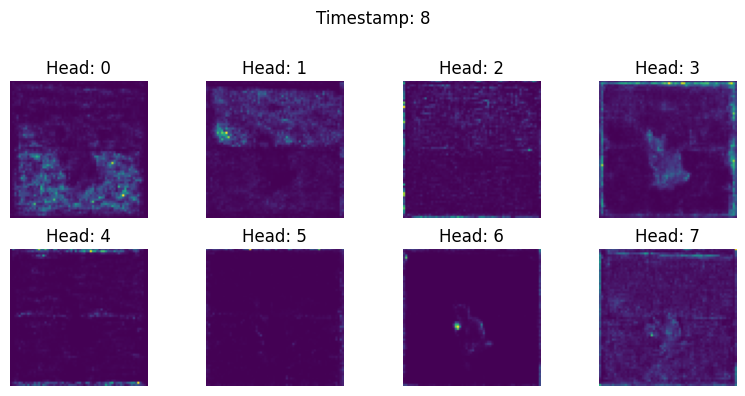

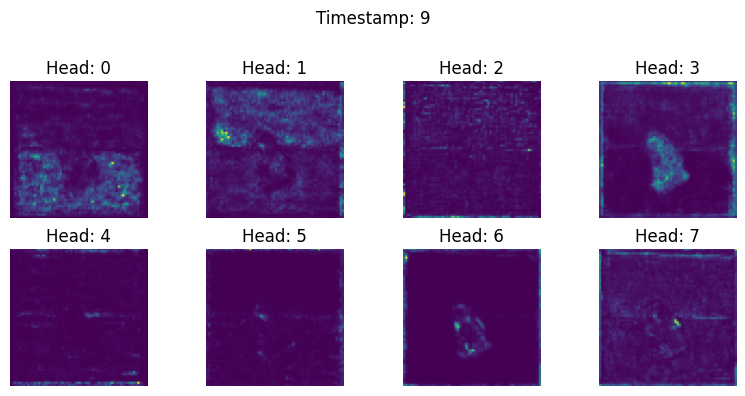

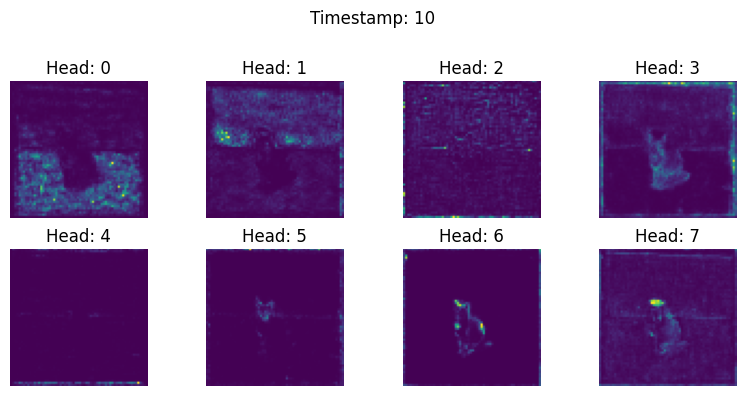

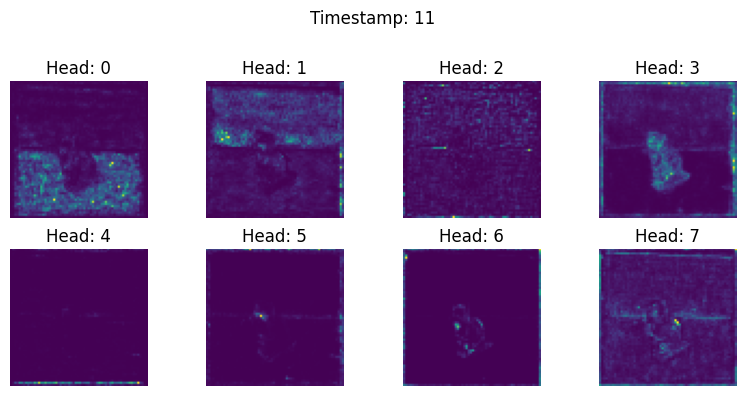

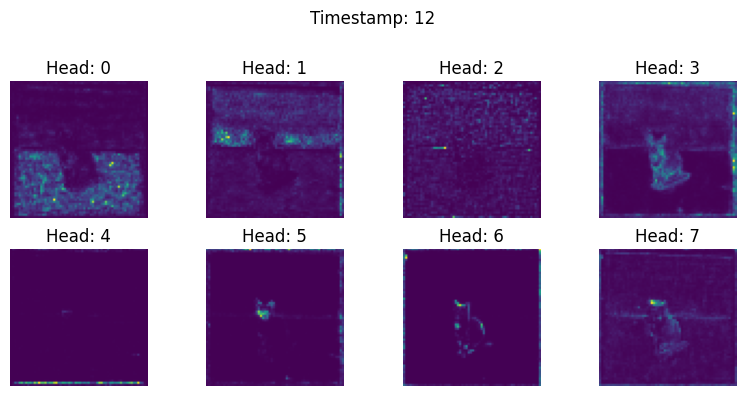

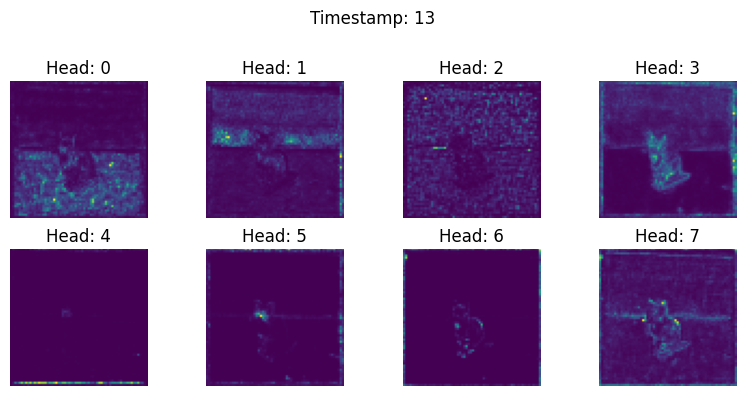

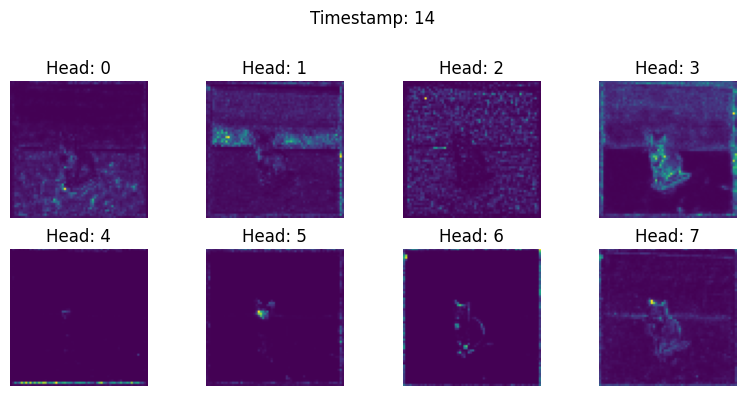

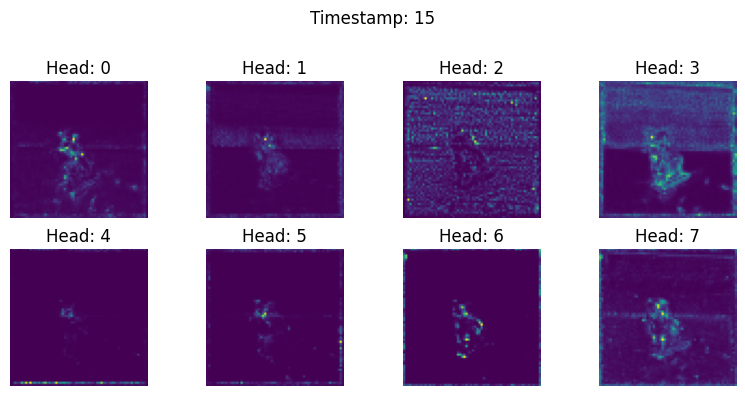

In [21]:
aggregated_viz(
    cross_attention_maps[layer_name],
    token_indices,
    title="Timestamp: {0}",
    subtitle="Head: {0}"
)

##### Aggregation by timestamps (mean)

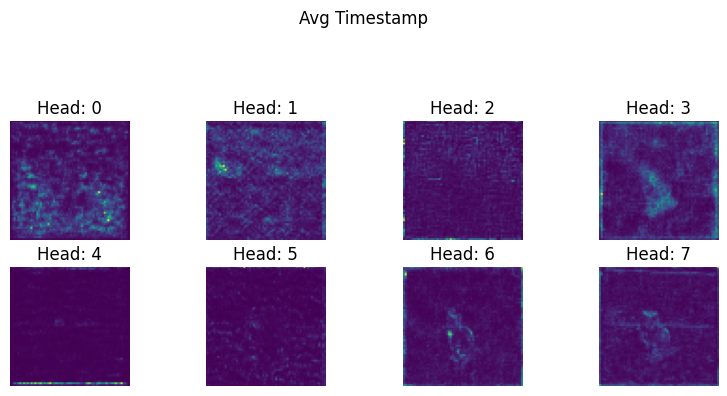

In [22]:
aggregated_viz(
    cross_attention_maps[layer_name],
    token_indices,
    title=f"Avg Timestamp",
    subtitle="Head: {0}",
    agg="mean",
    agg_dims=0,
    top=0.7
)

##### Aggregation by timestamps (max)

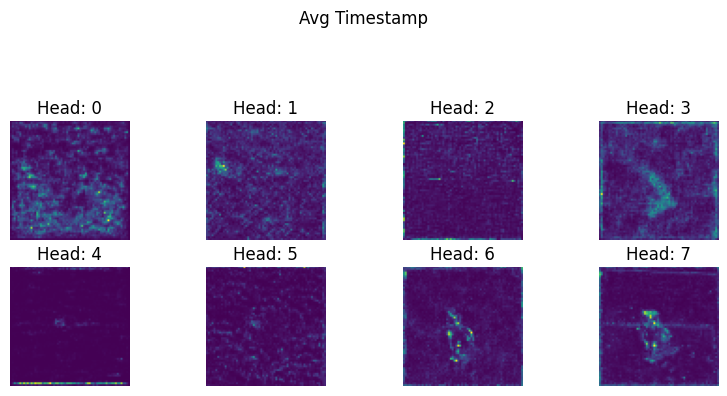

In [23]:
aggregated_viz(
    cross_attention_maps[layer_name],
    token_indices,
    title=f"Avg Timestamp",
    subtitle="Head: {0}",
    agg="max",
    agg_dims=0,
    top=0.7
)

##### Aggregation by attention heads (mean)

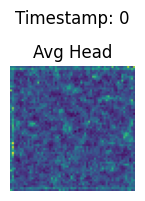

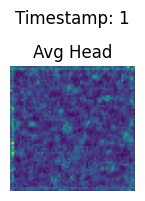

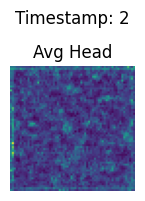

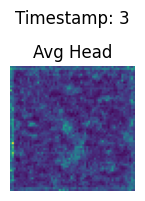

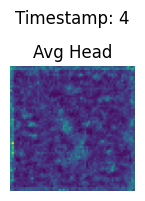

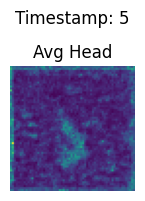

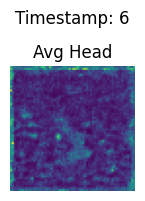

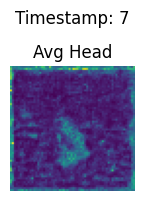

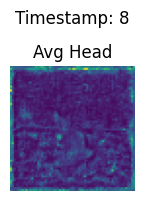

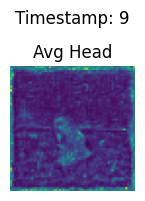

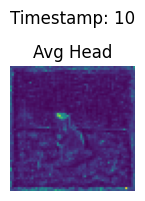

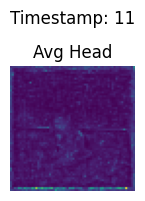

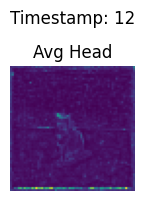

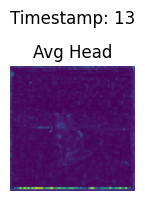

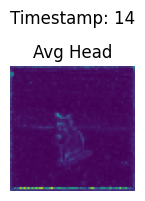

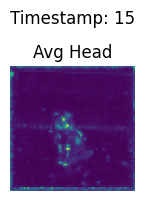

In [24]:
aggregated_viz(
    cross_attention_maps[layer_name],
    token_indices,
    title="Timestamp: {0}",
    subtitle="Avg Head",
    agg="mean",
    agg_dims=1,
    top=0.7
)

##### Aggregation by attention heads (max)

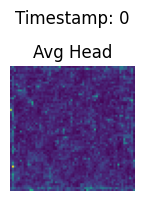

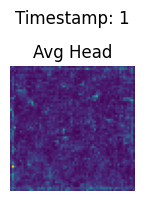

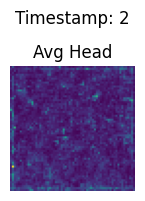

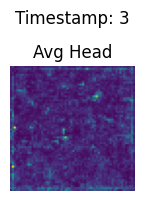

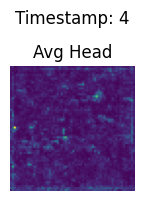

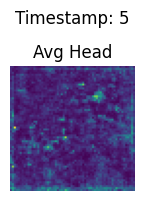

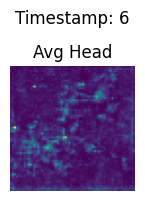

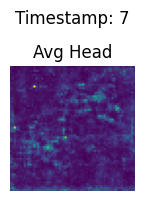

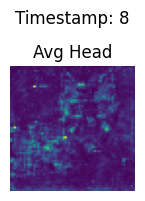

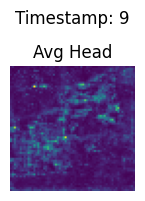

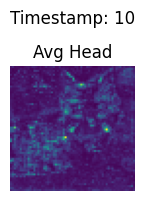

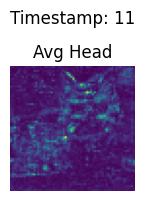

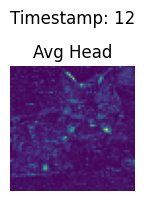

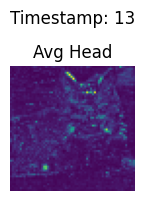

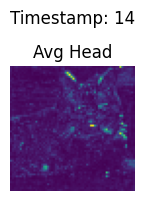

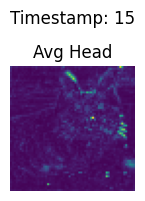

In [87]:
aggregated_viz(
    cross_attention_maps[layer_name],
    token_indices,
    title="Timestamp: {0}",
    subtitle="Avg Head",
    agg="max",
    agg_dims=1,
    top=0.7
)

##### Aggregation by timestamps and attention heads (mean)

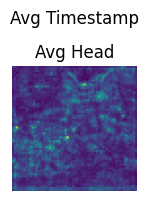

In [89]:
aggregated_viz(
    cross_attention_maps[layer_name],
    token_indices,
    title="Avg Timestamp",
    subtitle="Avg Head",
    agg="mean",
    agg_dims=(0, 1),
    top=0.7
)

##### Aggregation by timestamps and attention heads (max)

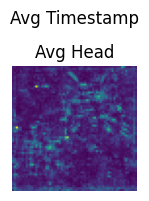

In [90]:
aggregated_viz(
    cross_attention_maps[layer_name],
    token_indices,
    title="Avg Timestamp",
    subtitle="Avg Head",
    agg="max",
    agg_dims=(0, 1),
    top=0.7
)

#### Making a Video

In [59]:
def prepare_maps_for_video(attn_maps, token_indices, size=64):
    amaps = []
    for layer_name in attn_maps:
        curr_maps = process_attn_maps(attn_maps[layer_name], token_indices)
        curr_maps = F.interpolate(curr_maps, size=(size, size), mode='bilinear', align_corners=True)
        amaps.append(curr_maps)

    amaps = torch.stack(amaps)
    # layer, timestamp, head, size, size

    amaps = amaps.permute(1, 2, 0, 3, 4)
    # timestamp, head, layer, size, size

    amaps = amaps.reshape(
        amaps.shape[0],
        amaps.shape[1] * amaps.shape[2],
        amaps.shape[3],
        amaps.shape[4]
    )
    # timestamp, head * layer, size, size

    return amaps

def make_video(attn_maps, nrows=8, overlap_with=None,
             out_file='animation.mp4', fps=5):
    frames = []
    for i in tqdm(range(len(attn_maps))):
        buf = make_image_grid(
            pt_to_img_list(attn_maps[i]),
            nrows=nrows,
            tight=True,
            overlap_with=overlap_with,
            return_buffer=True
        )
        frames.append(PIL.Image.open(buf))

    width, height = frames[0].size
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(out_file, fourcc, fps, (width, height))

    for frame in frames:
        frame = frame.convert("RGB")
        frame = np.array(frame)
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        video.write(frame)

    cv2.destroyAllWindows()
    video.release()

In [60]:
cam_prep = prepare_maps_for_video(cross_attention_maps, token_indices, size=64)
frames = make_video(
    cam_prep, nrows=8, fps=5,
    overlap_with=np.asarray(image.resize((64, 64)))
)

100%|██████████| 31/31 [01:35<00:00,  3.07s/it]
